In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

In [57]:
files = ["Хлопок.wav", "Хлопок_Заполненный_зал.wav", "Хлопок_металлический_бак.wav"]

БЕЗ НОРМИРОВКИ

In [58]:
results_raw = []

for file in files:
    fs, x = wavfile.read(file)
    x = x.astype(float)

    if x.ndim > 1:
        x = x.mean(axis=1)

    x_time = x.copy()
    t_time = np.arange(len(x_time)) / fs

    i0 = np.argmax(np.abs(x))
    x = x[i0:]
    t = np.arange(len(x)) / fs

    E = np.sum(x**2)
    exx = np.cumsum(x[::-1]**2)[::-1]
    exx_db = 10 * np.log10(exx / exx[0] + 1e-20)

    idx_60 = np.where(exx_db <= -60)[0]
    rt60 = t[idx_60[0]] if len(idx_60) else None

    results_raw.append({
        "file": file,
        "fs": fs,
        "x_time": x_time,
        "t_time": t_time,
        "x": x,
        "t": t,
        "E": E,
        "exx": exx,
        "exx_db": exx_db,
        "rt60": rt60
    })

In [59]:
print("БЕЗ НОРМИРОВКИ\n")

for r in results_raw:
    print(f"Файл: {r['file']}")
    print(f"Энергия сигнала: {r['E']:.6f}")
    if r["rt60"] is not None:
        print(f"RT60: {r['rt60']:.3f} с")
    else:
        print("RT60 не найден")
    print()

БЕЗ НОРМИРОВКИ

Файл: Хлопок.wav
Энергия сигнала: 2779036900.500000
RT60: 0.230 с

Файл: Хлопок_Заполненный_зал.wav
Энергия сигнала: 4415214011.750000
RT60: 0.833 с

Файл: Хлопок_металлический_бак.wav
Энергия сигнала: 5095270703.750000
RT60: 0.836 с



ГРАФИКИ БЕЗ НОРМИРОВКИ

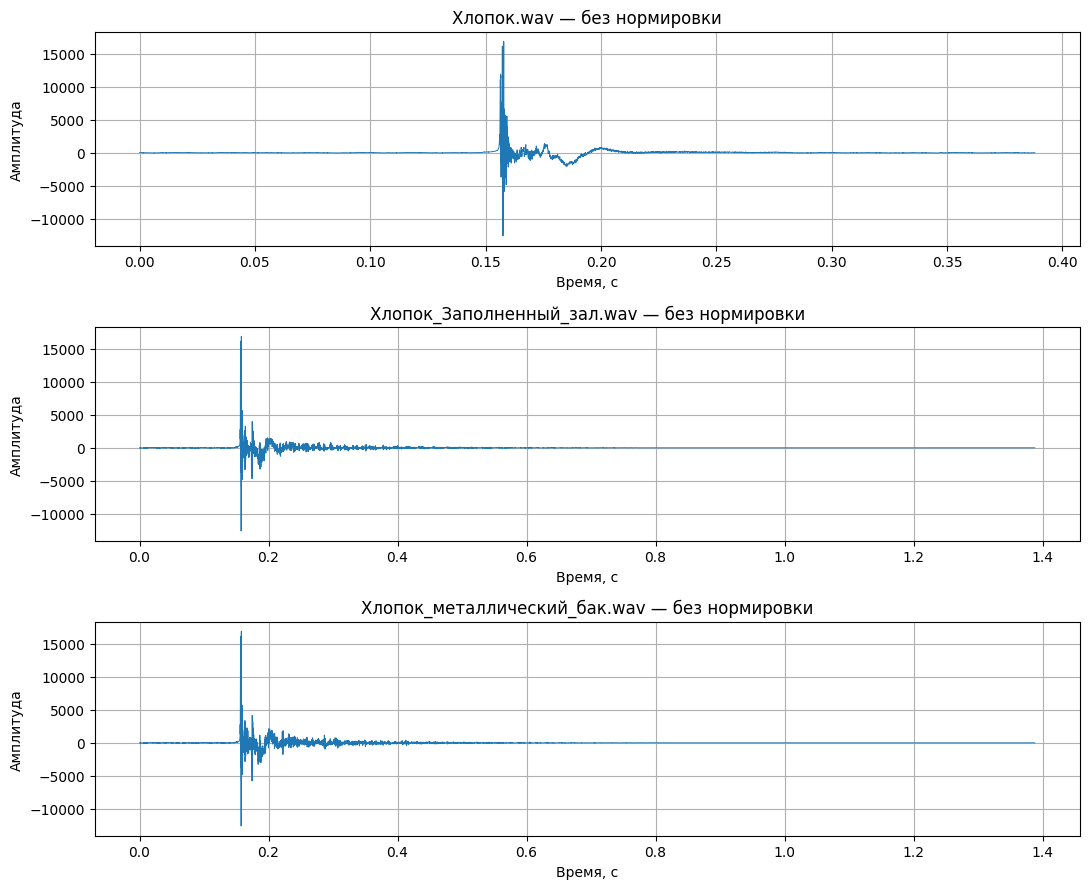

In [60]:
fig, axes = plt.subplots(len(results_raw), 1, figsize=(11, 3 * len(results_raw)), sharex=False)

if len(results_raw) == 1:
    axes = [axes]

for ax, r in zip(axes, results_raw):
    ax.plot(r["t_time"], r["x_time"], lw=0.7)
    ax.set_title(f"{r['file']} — без нормировки")
    ax.set_xlabel("Время, с")
    ax.set_ylabel("Амплитуда")
    ax.grid(True)

plt.tight_layout()
plt.show()

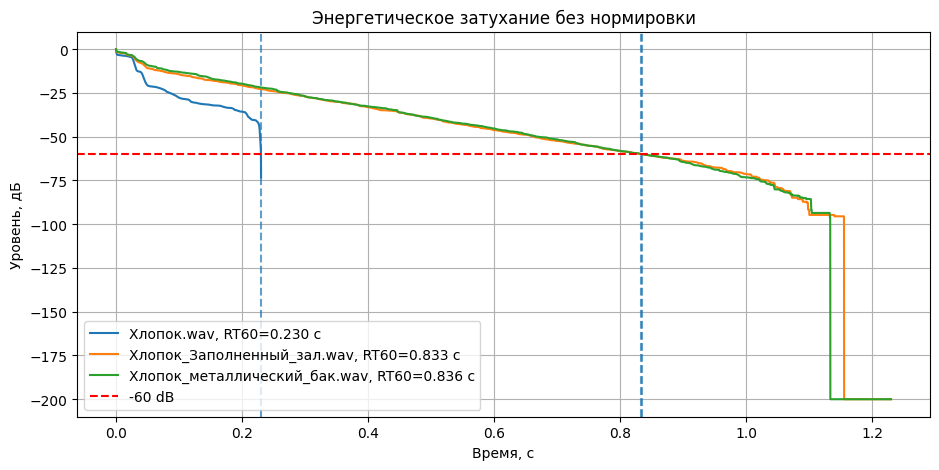

In [61]:
plt.figure(figsize=(11, 5))

for r in results_raw:
    label = f"{r['file']}, RT60={r['rt60']:.3f} c" if r["rt60"] is not None else f"{r['file']}, RT60 нет"
    plt.plot(r["t"], r["exx_db"], label=label)

    if r["rt60"] is not None:
        plt.axvline(r["rt60"], linestyle="--", alpha=0.7)

plt.axhline(-60, color="r", linestyle="--", label="-60 dB")
plt.title("Энергетическое затухание без нормировки")
plt.xlabel("Время, с")
plt.ylabel("Уровень, дБ")
plt.grid()
plt.legend()
plt.show()

С НОРМИРОВКОЙ

In [62]:
results_norm = []

for file in files:
    fs, x = wavfile.read(file)
    x = x.astype(float)

    if x.ndim > 1:
        x = x.mean(axis=1)

    x /= np.max(np.abs(x))

    x_time = x.copy()
    t_time = np.arange(len(x_time)) / fs

    i0 = np.argmax(np.abs(x))
    x = x[i0:]
    t = np.arange(len(x)) / fs

    E = np.sum(x**2)
    exx = np.cumsum(x[::-1]**2)[::-1]
    exx_db = 10 * np.log10(exx / exx[0] + 1e-20)

    idx_60 = np.where(exx_db <= -60)[0]
    rt60 = t[idx_60[0]] if len(idx_60) else None

    results_norm.append({
        "file": file,
        "fs": fs,
        "x_time": x_time,
        "t_time": t_time,
        "x": x,
        "t": t,
        "E": E,
        "exx": exx,
        "exx_db": exx_db,
        "rt60": rt60
    })

In [63]:
print("С НОРМИРОВКОЙ\n")

for r in results_norm:
    print(f"Файл: {r['file']}")
    print(f"Энергия сигнала: {r['E']:.6f}")
    if r["rt60"] is not None:
        print(f"RT60: {r['rt60']:.3f} с")
    else:
        print("RT60 не найден")
    print()

С НОРМИРОВКОЙ

Файл: Хлопок.wav
Энергия сигнала: 9.777565
RT60: 0.230 с

Файл: Хлопок_Заполненный_зал.wav
Энергия сигнала: 15.488204
RT60: 0.833 с

Файл: Хлопок_металлический_бак.wav
Энергия сигнала: 17.862148
RT60: 0.836 с



ГРАФИК С НОРМИРОВКОЙ

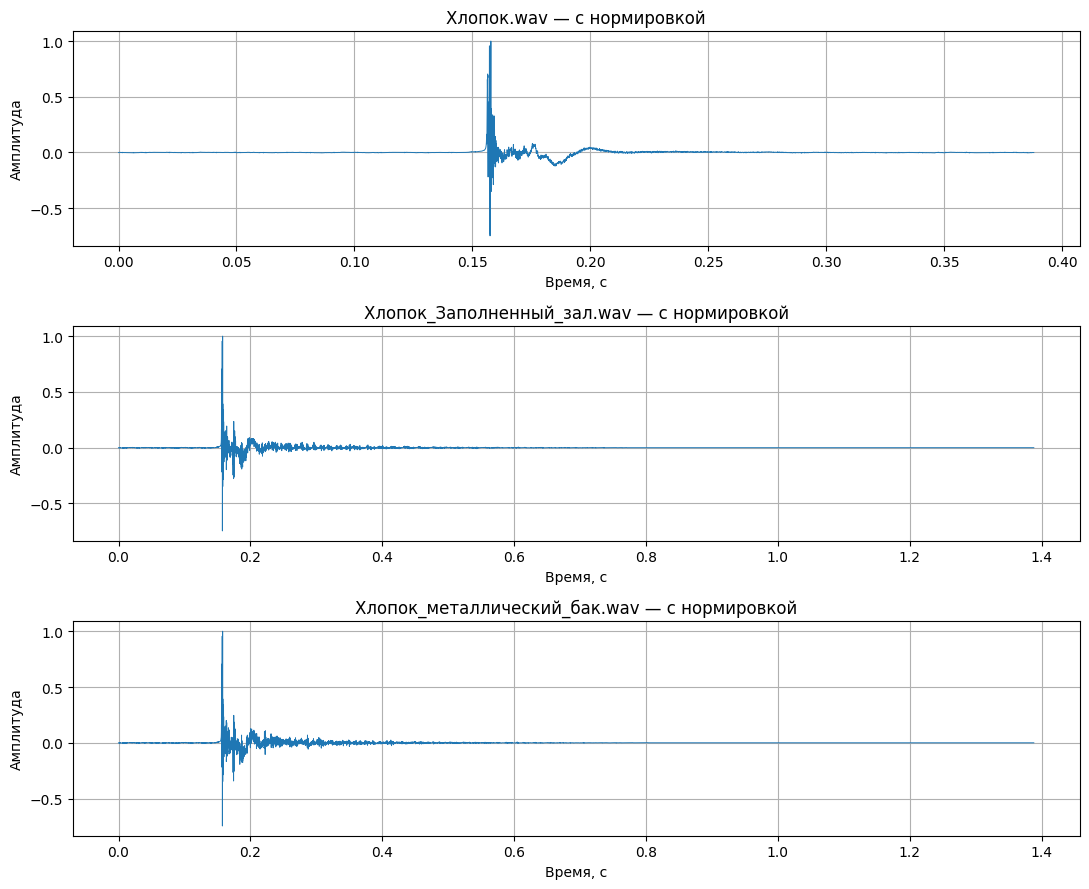

In [64]:
fig, axes = plt.subplots(len(results_norm), 1, figsize=(11, 3 * len(results_norm)), sharex=False)

if len(results_norm) == 1:
    axes = [axes]

for ax, r in zip(axes, results_norm):
    ax.plot(r["t_time"], r["x_time"], lw=0.7)
    ax.set_title(f"{r['file']} — с нормировкой")
    ax.set_xlabel("Время, с")
    ax.set_ylabel("Амплитуда")
    ax.grid(True)

plt.tight_layout()
plt.show()

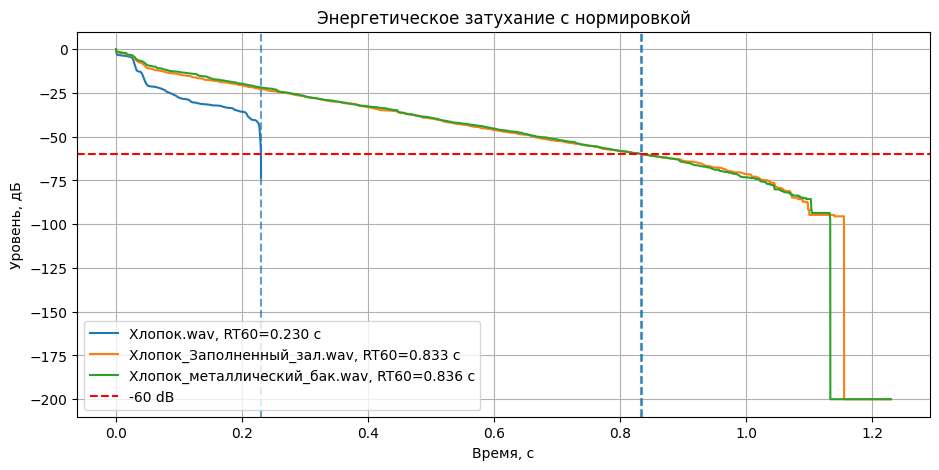

In [65]:
plt.figure(figsize=(11, 5))

for r in results_norm:
    label = f"{r['file']}, RT60={r['rt60']:.3f} c" if r["rt60"] is not None else f"{r['file']}, RT60 нет"
    plt.plot(r["t"], r["exx_db"], label=label)

    if r["rt60"] is not None:
        plt.axvline(r["rt60"], linestyle="--", alpha=0.7)

plt.axhline(-60, color="r", linestyle="--", label="-60 dB")
plt.title("Энергетическое затухание с нормировкой")
plt.xlabel("Время, с")
plt.ylabel("Уровень, дБ")
plt.grid()
plt.legend()
plt.show()

Графики в дБ получаются одинаковыми, потому что exx_db считается как 10*log10(exx / exx[0]).
При такой записи масштаб сигнала сокращается, поэтому нормировка влияет на энергию E,
но почти не влияет на форму кривой затухания и значение RT60.